# Tema : Modelos ARIMAX
![](src/img/logo_utb.png){width=40%} 
![](src/img/logo_etd.png){width=40%}
- **Profesor:**
- **Fernando Salcedo Mejía, Eco Msc.**
- Programa de Ciencias de Datos | Escuela de transformación digital.
- 2026-1

## Ejemplo 1 : El modelo macroeconómico del crecimiento del consumo en Estados Unidos

- Queremos modelar cómo cambia el consumo real (compra de bienes y servicios) de una economía según el incremento del ingreso.
$$
\Delta C_t = \beta_0 + \beta_1 \Delta Ingreso_t + \varepsilon_t
$$

- $\Delta C_t$ es el cambio porcentual en el gasto real de consumo personal.
- $Ingreso_t$​ es el cambio porcentual en el ingreso personal real disponible.

- Usar el archivo `US_change.csv` para modelar.

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.stattools import jarque_bera, durbin_watson
import warnings
warnings.filterwarnings('ignore')

# leer y ajustar datos
# Cargar datos US_change
us_change = pd.read_csv("../data/US_change.csv", parse_dates=["ds"])

# Formato
us_change["ds"] = pd.to_datetime(us_change["ds"])
us_change.set_index("ds", inplace=True)
us_change.index = pd.DatetimeIndex(us_change.index).to_period('Q').to_timestamp()

serie_consumo = us_change["y"]
serie_ingreso = us_change["Income"]

# Encabezado
us_change.head()

,y,Income,Production,Savings,Unemployment,unique_id
ds,,,,,,
1970-01-01,0.618566,1.044801,-2.452486,5.299014,0.9,US_change
1970-04-01,0.451984,1.225647,-0.551459,7.789894,0.5,US_change
1970-07-01,0.872872,1.585154,-0.358652,7.403984,0.5,US_change
1970-10-01,-0.271848,-0.239545,-2.185691,1.169898,0.7,US_change
1971-01-01,1.901345,1.975925,1.909764,3.535667,-0.1,US_change


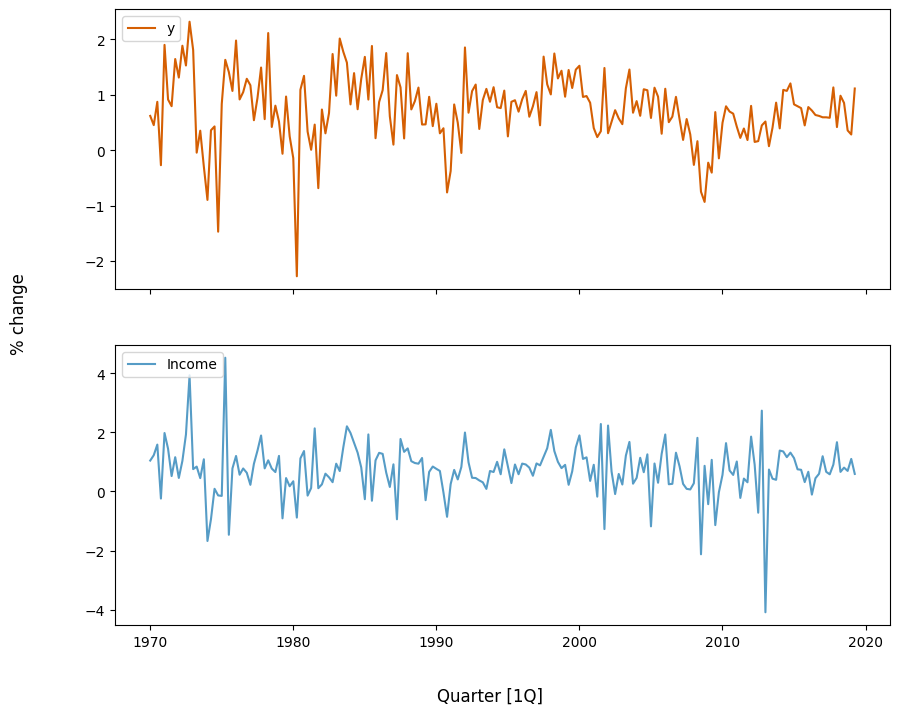

In [82]:
columns = ["y", "Income"]
colors = ["#D55F03", "#569CC6"]

fig, axes = plt.subplots(nrows=len(columns), ncols=1, sharex=True, figsize=(10, 8))
for i, var in enumerate(columns):
    axes[i].plot(us_change.index, us_change[var], label=var, color = colors[i])
    axes[i].legend(loc='upper left')
fig.supxlabel("Quarter [1Q]")
fig.supylabel("% change")
plt.show()

In [83]:
def test_estacionariedad(datos):
    # Augmented Dickey-Fuller
    adf_result = adfuller(datos)
    # KPSS
    kpss_result = kpss(datos, regression='c')

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Prueba Augmented Dickey-Fuller (ADF)", "Prueba KPSS"],
        'Estadístico' : [round(adf_result[0],  4), round(kpss_result[0],  4)],
        'P-valor'     : [round(adf_result[1], 4), round(kpss_result[1], 4)],
        "Estacionario" : ["Sí" if adf_result[1] < 0.05 else "No", "No" if kpss_result[1] < 0.05 else "Sí"]
    })

    print("=" * 80)
    print("PRUEBA DE ESTACIONARIEDAD")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)


print("Prueba consumo")
test_estacionariedad(serie_consumo)
print("\nPrueba ingreso")
test_estacionariedad(serie_ingreso)

Prueba consumo
PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)      -4.6101   0.0001           Sí
1                           Prueba KPSS       0.2212   0.1000           Sí

Prueba ingreso
PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)      -6.7656      0.0           Sí
1                           Prueba KPSS       0.1619      0.1           Sí


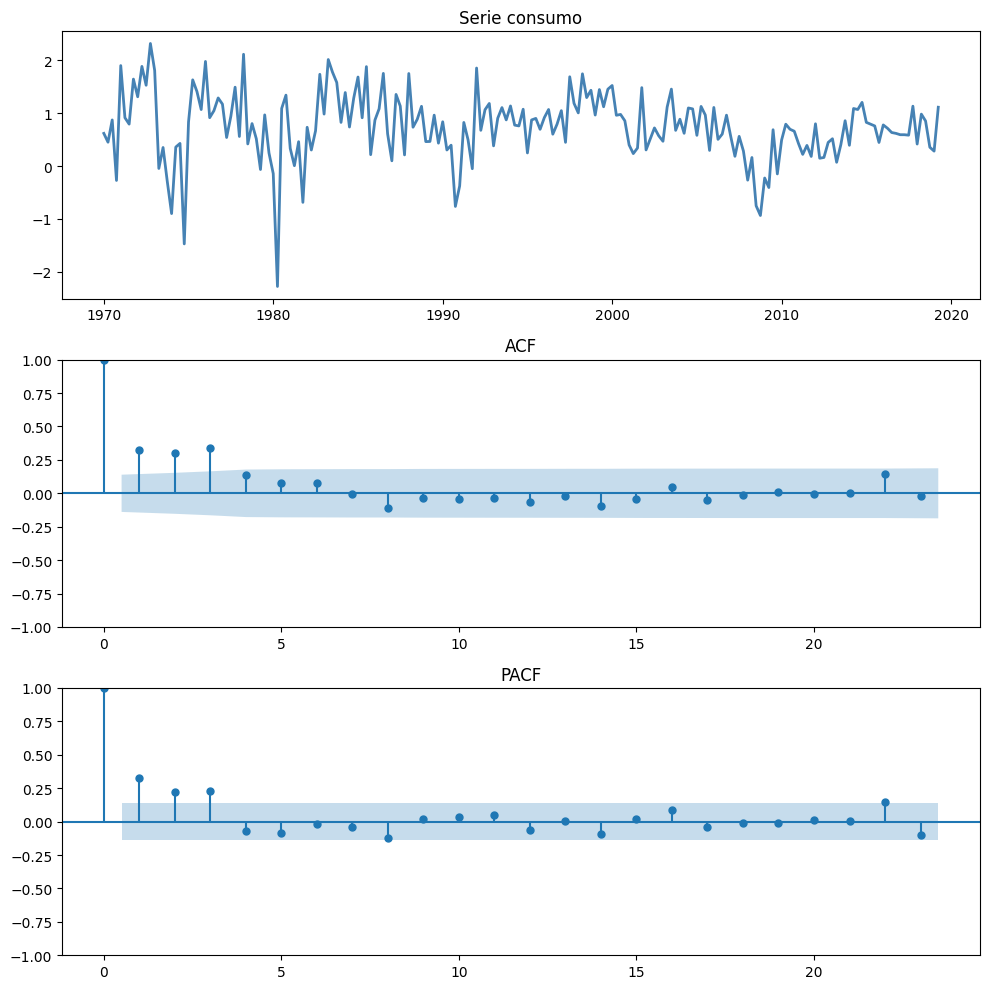

In [84]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(serie_consumo.index, serie_consumo, color='steelblue', linewidth=2)
axes[0].set_title('Serie consumo')
plot_acf(serie_consumo, ax=axes[1], title=f'ACF')
plot_pacf(serie_consumo, ax=axes[2], title=f'PACF')
plt.tight_layout()
plt.show()

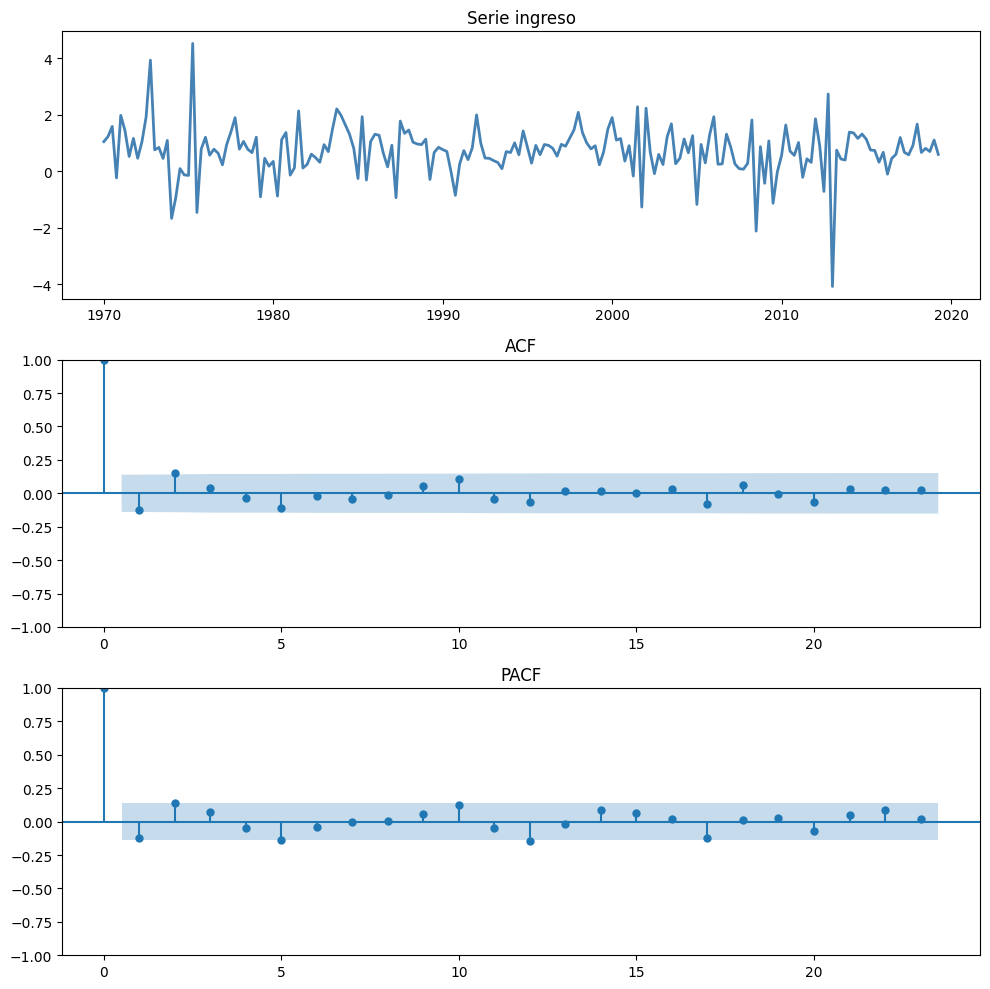

In [85]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(serie_ingreso.index, serie_ingreso, color='steelblue', linewidth=2)
axes[0].set_title('Serie ingreso')
plot_acf(serie_ingreso, ax=axes[1], title=f'ACF')
plot_pacf(serie_ingreso, ax=axes[2], title=f'PACF')
plt.tight_layout()
plt.show()

In [86]:
# ARIMA(0, 0, 3)
arima003 = ARIMA(serie_consumo, exog=serie_ingreso, order=(0, 0, 3)).fit()
print(arima003.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  198
Model:                 ARIMA(0, 0, 3)   Log Likelihood                -164.733
Date:                Sun, 05 Apr 2026   AIC                            341.465
Time:                        18:19:07   BIC                            361.195
Sample:                    01-01-1970   HQIC                           349.451
                         - 04-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6072      0.065      9.280      0.000       0.479       0.735
Income         0.1848      0.036      5.204      0.000       0.115       0.254
ma.L1          0.1192      0.066      1.801      0.0

In [87]:
# ARIMA(3, 0, 1)
arima301 = ARIMA(serie_consumo, exog=serie_ingreso, order=(3, 0, 1)).fit()
print(arima301.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  198
Model:                 ARIMA(3, 0, 1)   Log Likelihood                -162.708
Date:                Sun, 05 Apr 2026   AIC                            339.415
Time:                        18:19:07   BIC                            362.433
Sample:                    01-01-1970   HQIC                           348.732
                         - 04-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6046      0.087      6.982      0.000       0.435       0.774
Income         0.1848      0.034      5.389      0.000       0.118       0.252
ar.L1          0.0451      0.344      0.131      0.8

In [88]:
# Autoarima
autoarima = auto_arima(serie_consumo, exog=serie_ingreso, d=0, sesional=False, trace = True, stepwise=False, approximation=False)

 ARIMA(0,0,0)(0,0,0)[1] intercept   : AIC=386.843, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[1] intercept   : AIC=372.948, Time=0.02 sec
 ARIMA(0,0,2)(0,0,0)[1] intercept   : AIC=369.558, Time=0.03 sec
 ARIMA(0,0,3)(0,0,0)[1] intercept   : AIC=353.193, Time=0.03 sec
 ARIMA(0,0,4)(0,0,0)[1] intercept   : AIC=354.497, Time=0.07 sec
 ARIMA(0,0,5)(0,0,0)[1] intercept   : AIC=354.625, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[1] intercept   : AIC=366.649, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[1] intercept   : AIC=355.926, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[1] intercept   : AIC=354.467, Time=0.05 sec
 ARIMA(1,0,3)(0,0,0)[1] intercept   : AIC=351.766, Time=0.05 sec
 ARIMA(1,0,4)(0,0,0)[1] intercept   : AIC=353.569, Time=0.12 sec
 ARIMA(2,0,0)(0,0,0)[1] intercept   : AIC=358.963, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[1] intercept   : AIC=356.166, Time=0.07 sec
 ARIMA(2,0,2)(0,0,0)[1] intercept   : AIC=353.039, Time=0.10 sec
 ARIMA(2,0,3)(0,0,0)[1] intercept   : AIC=353.285, Time=0.10 sec
 ARIMA(3,0,0)(0,0,0)[1] i

In [89]:
# ARIMA optimo
auto_arima_optimo = ARIMA(serie_consumo, exog=serie_ingreso, order=autoarima.order).fit()
print(auto_arima_optimo.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  198
Model:                 ARIMA(3, 0, 0)   Log Likelihood                -162.727
Date:                Sun, 05 Apr 2026   AIC                            337.454
Time:                        18:19:09   BIC                            357.183
Sample:                    01-01-1970   HQIC                           345.440
                         - 04-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6035      0.087      6.930      0.000       0.433       0.774
Income         0.1861      0.034      5.429      0.000       0.119       0.253
ar.L1          0.1081      0.065      1.663      0.0

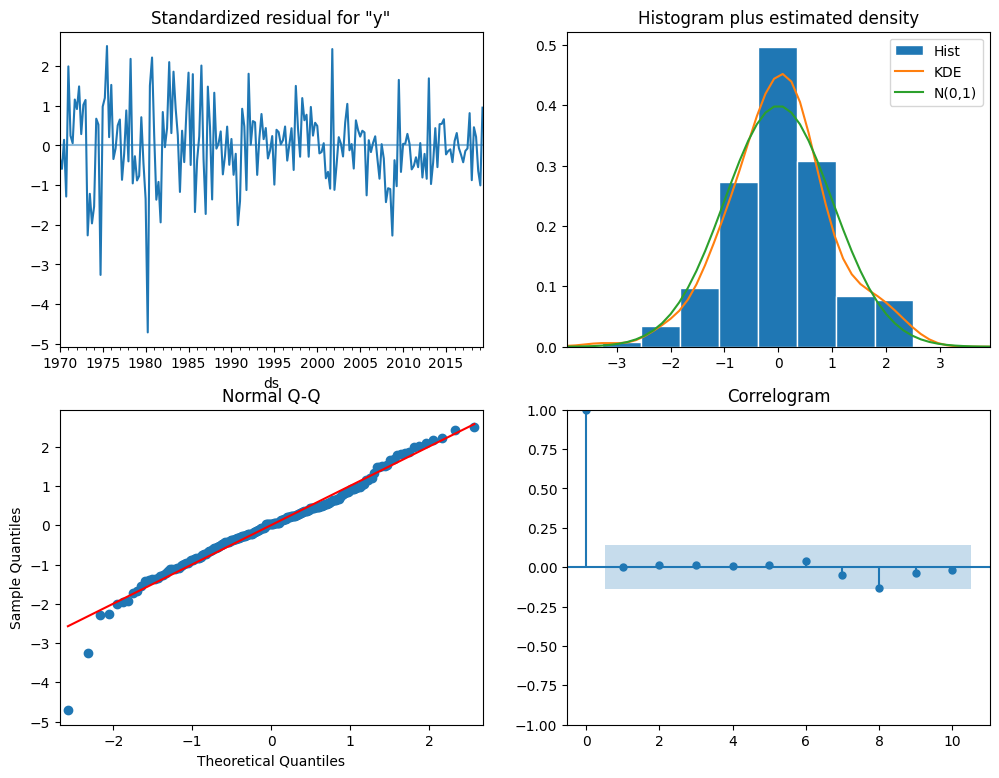

In [90]:
auto_arima_optimo.plot_diagnostics(figsize=(12, 9))
plt.show()

## Ejemplo 3 : Gasto en publicidad por televisión y cotizaciones de seguros

Una empresa de seguro en EEUU está interesada en saber si el gasto en publicidad por televisión influye en el valor de los aportes de aseguramiento. Para ello tiene dos series de tiempo, uno con el gasto en publicidad y la otra en aportes de seguro que realiza los clientes.

In [91]:
# librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

# Datos de seguros
seguros = pd.read_csv('../data/insurance.csv', parse_dates=['ds'])
seguros = seguros.set_index('ds')
seguros.index = pd.DatetimeIndex(seguros.index).to_period('M').to_timestamp()
seguros.rename(columns={"Quotes" : "Aportes", "TVadverts" : "Gasto_publicidad"}, inplace=True)

# series
aportes = seguros.Aportes
gasto_publicidad = seguros.Gasto_publicidad

seguros.head()


,unique_id,Aportes,Gasto_publicidad
ds,,,
2002-01-01,insurance,12.97065,7.212725
2002-02-01,insurance,15.38714,9.443570
2002-03-01,insurance,13.22957,7.534250
2002-04-01,insurance,12.97065,7.212725
2002-05-01,insurance,15.38714,9.443570


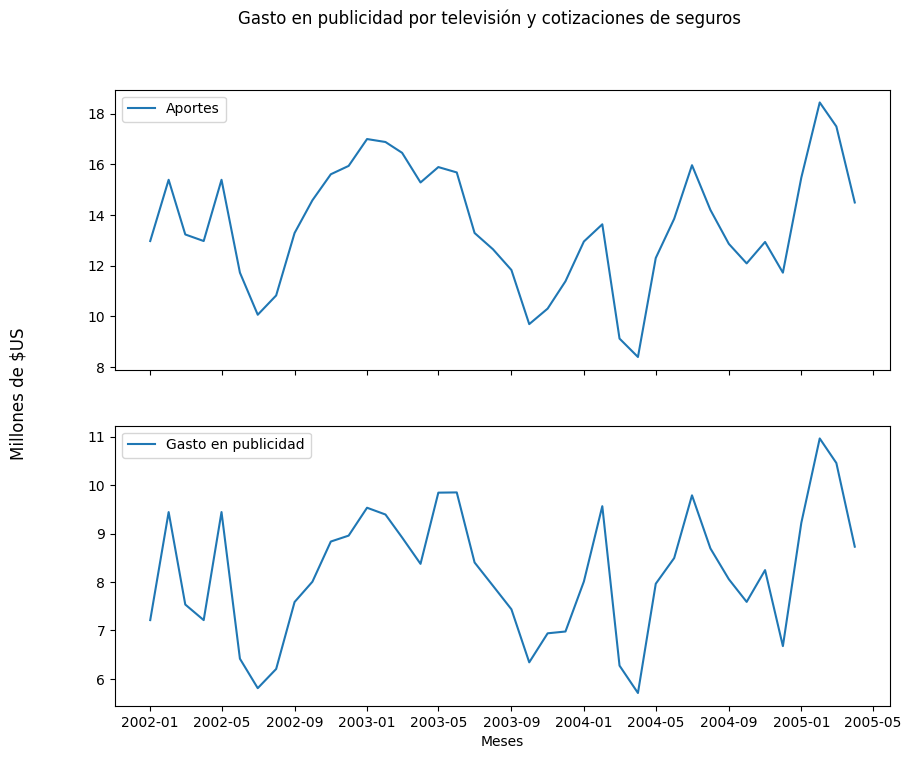

In [92]:
fig, axes = plt.subplots(2, figsize=(10, 8),  sharex=True)
axes[0].plot(seguros.index, seguros["Aportes"], label = "Aportes")
axes[0].legend(loc='upper left')
axes[1].plot(seguros.index, seguros["Gasto_publicidad"], label = "Gasto en publicidad")
axes[1].legend(loc='upper left')
axes[1].set(xlabel="Meses")
fig.suptitle("Gasto en publicidad por televisión y cotizaciones de seguros")
fig.supylabel("Millones de $US")
plt.show()

## EDA correlación series
- Correlación entre las series y sus rezagos en el gasto de publicidad  $Corr(y_t, x_{t-k})$

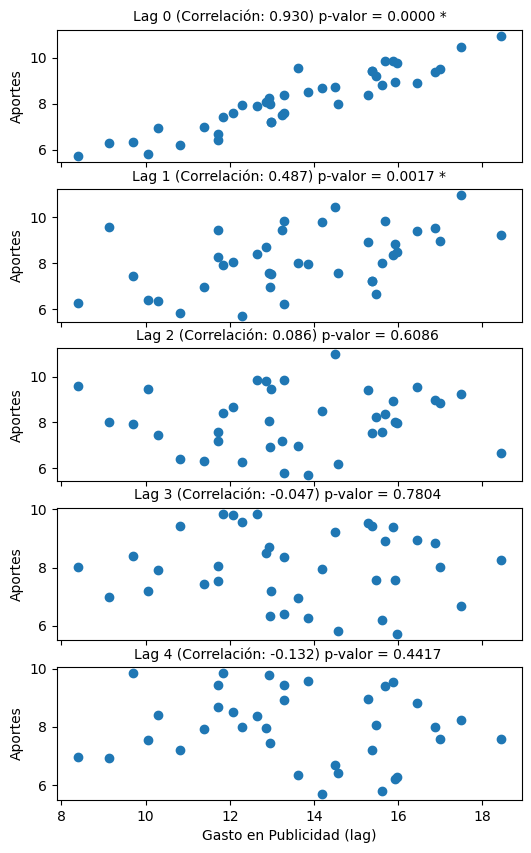

In [93]:
from scipy.stats import pearsonr

lags = range(5)
fig, axes = plt.subplots(nrows=len(lags), ncols=1, sharex=True, figsize=(6, 10))
for i in lags:
    gasto_publicidad_lag = gasto_publicidad.shift(i)
    index_notna = gasto_publicidad_lag.notna()
    aportes_info = aportes[index_notna]
    gasto_lag_info = gasto_publicidad_lag[index_notna]

    corr, p_valor = pearsonr(aportes_info, gasto_lag_info)
    sign_pvalor = "*" if p_valor < 0.05 else ""
    texto_info = f"Lag {i} (Correlación: {corr:.3f}) p-valor = {p_valor:.4f} {sign_pvalor}"

    axes[i].scatter(aportes, gasto_publicidad_lag)
    axes[i].set_title(texto_info, fontsize=10)
    axes[i].set_ylabel("Aportes")

    if i == lags[-1]:
        axes[i].set_xlabel("Gasto en Publicidad (lag)")
plt.show()

In [94]:
def test_estacionariedad(datos):
    # Augmented Dickey-Fuller
    adf_result = adfuller(datos)
    # KPSS
    kpss_result = kpss(datos, regression='c')

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Prueba Augmented Dickey-Fuller (ADF)", "Prueba KPSS"],
        'Estadístico' : [round(adf_result[0],  4), round(kpss_result[0],  4)],
        'P-valor'     : [round(adf_result[1], 4), round(kpss_result[1], 4)],
        "Estacionario" : ["Sí" if adf_result[1] < 0.05 else "No", "No" if kpss_result[1] < 0.05 else "Sí"]
    })

    print("=" * 80)
    print("PRUEBA DE ESTACIONARIEDAD")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)

test_estacionariedad(gasto_publicidad)
test_estacionariedad(aportes)

PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)      -4.2931   0.0005           Sí
1                           Prueba KPSS       0.1487   0.1000           Sí
PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)      -3.4231   0.0102           Sí
1                           Prueba KPSS       0.1006   0.1000           Sí


## Modelos :

- Modelo base sin rezago

$$
Aportes_t = \beta_0 + \beta_1 Publicidad_t + \eta_t \\
\eta_t \sim \text{ARMA(p, q)}
$$

- Modelo con 1 rezago

$$
Aportes_t = \beta_0 + \beta_1 Publicidad_t + \beta_2 Publicidad_{t - 1} + \eta_t \\
\eta_t \sim \text{ARMA(p, q)}
$$

- Modelo con 2 rezagos

$$
Aportes_t = \beta_0 + \beta_1 Publicidad_t + \beta_2 Publicidad_{t - 1} + \beta_3 Publicidad_{t - 2} + \eta_t \\
\eta_t \sim \text{ARMA(p, q)}
$$

- Modelo con 3 rezagos

$$
Aportes_t = \beta_0 + \beta_1 Publicidad_t + \beta_2 Publicidad_{t - 1} + \beta_3 Publicidad_{t - 2} +  \beta_4 Publicidad_{t - 3} + \eta_t \\
\eta_t \sim \text{ARMA(p, q)}
$$

> Como nuestro objetivo es comparar modelos, es **importante mantener el mismo set de entrenamiento** o estimación entre todos los modelos. Si no, estaremos comparando modelos con diferentes ventanas de estimación.

In [95]:
# Datos modelos rezagos 1-3
# Se crea un dataframe con los rezagos
n_rezagos = 3
datos_modelo = seguros.copy()
for i in range(1, n_rezagos + 1):
    datos_modelo[f"Gasto_publicidad_lag{i}"] = datos_modelo["Gasto_publicidad"].shift(i)

datos_modelo.dropna(inplace = True)
datos_modelo.head()

,unique_id,Aportes,Gasto_publicidad,Gasto_publicidad_lag1,Gasto_publicidad_lag2,Gasto_publicidad_lag3
ds,,,,,,
2002-04-01,insurance,12.97065,7.212725,7.534250,9.443570,7.212725
2002-05-01,insurance,15.38714,9.443570,7.212725,7.534250,9.443570
2002-06-01,insurance,11.72288,6.415215,9.443570,7.212725,7.534250
2002-07-01,insurance,10.06177,5.806990,6.415215,9.443570,7.212725
2002-08-01,insurance,10.82279,6.203600,5.806990,6.415215,9.443570


In [96]:
# modelo sin rezagos
auto_arimax_0 = auto_arima(y = datos_modelo["Aportes"], x = datos_modelo["Gasto_publicidad"], d= 0, sesional=False, trace = False)

# mejor modelo ARMA(p, q)
arimax_0 = ARIMA(seguros["Aportes"], exog=seguros["Gasto_publicidad"], order=auto_arimax_0.order).fit()
print(arimax_0.summary())

# guardar modelo
list_modelo_arimax = {"arimax_0" : arimax_0}

                               SARIMAX Results                                
Dep. Variable:                Aportes   No. Observations:                   40
Model:                 ARIMA(0, 0, 2)   Log Likelihood                 -31.454
Date:                Sun, 05 Apr 2026   AIC                             72.908
Time:                        18:19:12   BIC                             81.352
Sample:                    01-01-2002   HQIC                            75.961
                         - 04-01-2005                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                3.7978      0.617      6.154      0.000       2.588       5.007
Gasto_publicidad     1.2012      0.064     18.762      0.000       1.076       1.327
ma.L1                1.2322 

In [97]:
# Modelo rezago 1-3
vars_rezagos = ["Gasto_publicidad"]
for i in range(1, n_rezagos + 1):
    vars_rezagos.append(f"Gasto_publicidad_lag{i}")    
    # autoarima
    auto_arimax_lag = auto_arima(y = datos_modelo["Aportes"], x = datos_modelo[vars_rezagos], d= 0, sesional=False, trace = False)
    # mejor modelo ARMA(p, q)
    fit_arimax_lag = ARIMA(datos_modelo["Aportes"], exog=datos_modelo[vars_rezagos], order=auto_arimax_lag.order).fit()
    # guardar modelo
    list_modelo_arimax[f"arimax_{i}"] = fit_arimax_lag

# print modelo con tres rezagos
print(list_modelo_arimax["arimax_3"].summary())


                               SARIMAX Results                                
Dep. Variable:                Aportes   No. Observations:                   37
Model:                 ARIMA(0, 0, 2)   Log Likelihood                 -24.808
Date:                Sun, 05 Apr 2026   AIC                             65.615
Time:                        18:19:13   BIC                             78.503
Sample:                    04-01-2002   HQIC                            70.159
                         - 04-01-2005                                         
Covariance Type:                  opg                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     1.2342      2.235      0.552      0.581      -3.147       5.615
Gasto_publicidad          1.3536      0.089     15.126      0.000       1.178       1.529
Gasto_pu

In [98]:
# Comparacion de modelos
def comparar_modelos_arima(modelos: dict) -> pd.DataFrame:
    df_modelos = (
        pd.DataFrame({
            "Modelo"  : list(modelos),
            "Orden ARMA eta" : [m.model.order for m in modelos.values()],
            "AIC"     : [m.aic       for m in modelos.values()],
            "AICc"    : [m.aicc      for m in modelos.values()],
            "BIC"     : [m.bic       for m in modelos.values()],
            "Log-Lik" : [m.llf       for m in modelos.values()],
            "MSE"     : [m.mse       for m in modelos.values()],
            "RMSE"    : [m.mse**0.5  for m in modelos.values()],
            "MAE"     : [m.mae       for m in modelos.values()],
            "Params"  : [m.df_model  for m in modelos.values()],
            "Obs"     : [m.nobs      for m in modelos.values()],
        })
        .sort_values("AICc")
        .assign(Ranking=lambda df: range(1, len(df) + 1))
        .set_index("Ranking")
    )

    mejor      = df_modelos.iloc[0]["Modelo"]
    mejor_aicc = df_modelos.iloc[0]["AICc"]

    print("=" * 100)
    print("COMPARACIÓN DE MODELOS ARIMA")
    print("=" * 100)
    print(df_modelos.to_string())
    print("-" * 100)
    print(f"Mejor modelo (menor AICc): {mejor}  →  AICc: {mejor_aicc}")
    print("=" * 100)

comparar_modelos_arima(list_modelo_arimax)

COMPARACIÓN DE MODELOS ARIMA
           Modelo Orden ARMA eta        AIC       AICc        BIC    Log-Lik       MSE      RMSE       MAE  Params  Obs
Ranking                                                                                                                
1        arimax_1      (0, 0, 2)  61.816006  64.616006  71.481514 -24.908003  0.227671  0.477149  0.376609       6   37
2        arimax_2      (0, 0, 2)  63.812578  67.674647  75.089004 -24.906289  0.227750  0.477231  0.375938       7   37
3        arimax_3      (0, 0, 2)  65.615201  70.758059  78.502545 -24.807601  0.226312  0.475723  0.371228       8   37
4        arimax_0      (0, 0, 2)  72.907967  74.672673  81.352364 -31.453984  0.274048  0.523496  0.429802       5   40
----------------------------------------------------------------------------------------------------
Mejor modelo (menor AICc): arimax_1  →  AICc: 64.61600612931603


## Selección mejor modelo

- El mejor modelo (con el valor de AICc más pequeño) es lag 1 con dos predictores; es decir, incluye la publicidad únicamente en el mes actual y en el mes anterior. Por lo tanto, ahora reestimamos ese modelo, pero utilizando todos los datos disponibles.

$$
Aportes_t = 1.4007 + 1.3235 Publicidad_t + 0.1669 Publicidad_{t - 1} + \eta_t \\
\eta_t = 1.2716 \varepsilon_t + 0.7477 \varepsilon_{t-1} \\
\varepsilon_t \sim WN(0, 0.2094)
$$

- Intercepto (1.4007): Si no hubiera inversión en publicidad hoy ni ayer, se esperarían en promedio aproximadamente 1.40 unidades de aportes.

- Efecto inmmediato del gasto en publicidad (1.3235): Por cada unidad que aumente el gasto en publicidad hoy, los aportes aumentan en promedio 1.32 unidades.

- Efecto retardado del gasto en publicidad (0.1669): El gasto en publicidad del mes anterior aún tiene un efecto positivo residual en los aportes actuales.

- Error transferido ($\eta_t$​): Representa todo lo que afecta a los aportes que no es publicidad (ruido, competencia, etc.).Está compuesto por el choque aleatorio presente y un choque aleatorio del periodo anterior. Si hubo un evento inesperado el mes pasado, el 74.7% de ese efecto aún persiste en el error de este mes.- 

In [99]:
# set de datos completos
datos_modelo_final = seguros.copy()
datos_modelo_final["Gasto_publicidad_lag1"] = datos_modelo_final["Gasto_publicidad"].shift(1)
datos_modelo_final.dropna(inplace = True)

# Estimacion del modelo final
vars_rezagos = ["Gasto_publicidad", "Gasto_publicidad_lag1"]
auto_arimax_lag = auto_arima(y = datos_modelo_final["Aportes"], x = datos_modelo_final[vars_rezagos], d= 0, sesional=False, trace = False)
# mejor modelo ARMA(p, q)
mejor_arimax_lag = ARIMA(datos_modelo_final["Aportes"], exog=datos_modelo_final[vars_rezagos], order=auto_arimax_lag.order).fit()

# resultados
print(mejor_arimax_lag.summary())

                               SARIMAX Results                                
Dep. Variable:                Aportes   No. Observations:                   39
Model:                 ARIMA(0, 0, 2)   Log Likelihood                 -26.042
Date:                Sun, 05 Apr 2026   AIC                             64.085
Time:                        18:19:14   BIC                             74.066
Sample:                    02-01-2002   HQIC                            67.666
                         - 04-01-2005                                         
Covariance Type:                  opg                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     1.4007      0.916      1.529      0.126      -0.395       3.196
Gasto_publicidad          1.3235      0.075     17.679      0.000       1.177       1.470
Gasto_pu

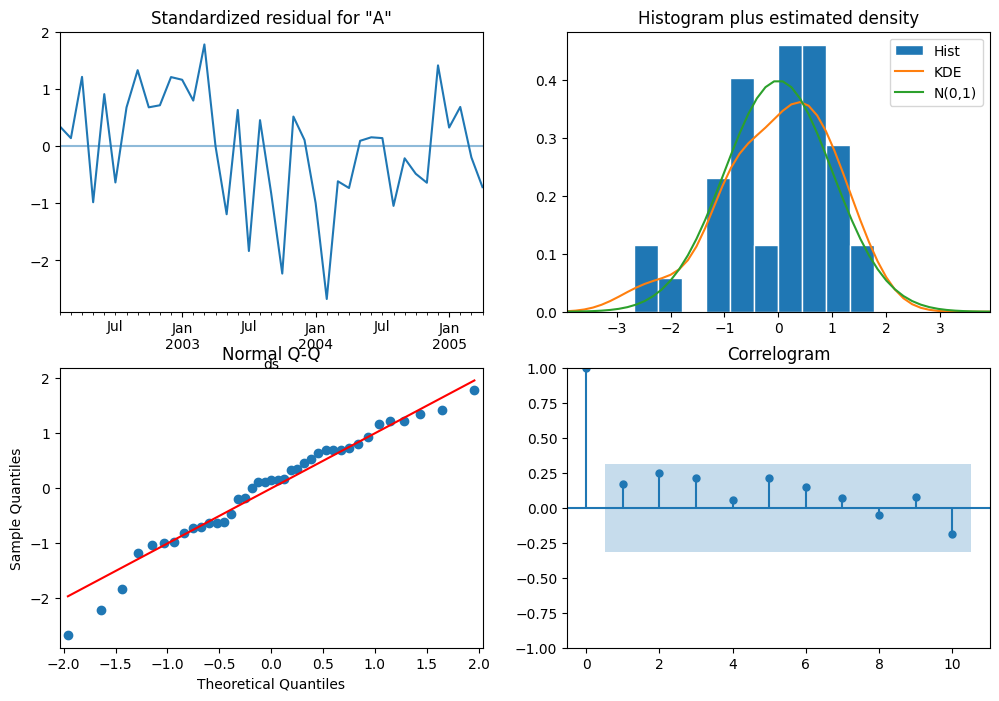

In [100]:
# Verificar ruido blanco
# Diagnostico del modelo
mejor_arimax_lag.plot_diagnostics(figsize=(12,8))
plt.show()

## Pronósticos
- Podemos calcular pronósticos utilizando este modelo si asumimos valores futuros para la variable de publicidad.
- Si fijamos la publicidad mensual futura en 8 unidades ¿Cúal sera el efecto en los aportes esperados en 8 meses?

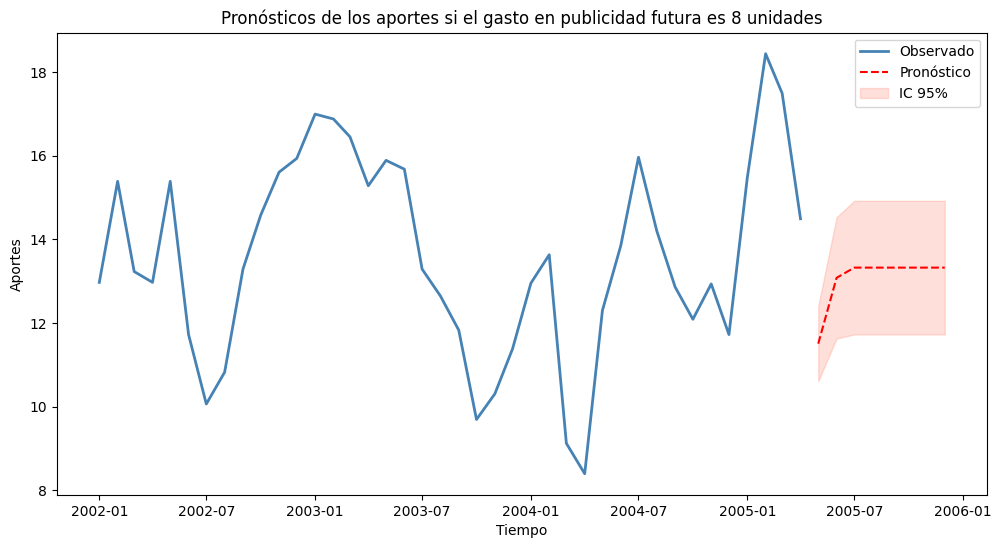

            Pronóstico  IC Inferior  IC Superior
Fecha                                           
2005-05-01   11.504685    10.607889    12.401481
2005-06-01   13.078513    11.627742    14.529284
2005-07-01   13.323668    11.725442    14.921895
2005-08-01   13.323668    11.725442    14.921895
2005-09-01   13.323668    11.725442    14.921895
2005-10-01   13.323668    11.725442    14.921895
2005-11-01   13.323668    11.725442    14.921895
2005-12-01   13.323668    11.725442    14.921895


In [101]:
# Pronostico de los proximos 8 meses
ult_fecha = seguros.index[-1]
fechas_futuras = pd.date_range(start=ult_fecha + pd.offsets.MonthBegin(1), periods=8, freq='MS')

# fijar publicidad en 8
gasto_publicidad_pronostico = pd.DataFrame({'Gasto_publicidad': [8] * 8}, index=fechas_futuras)
gasto_publicidad_pronostico["Gasto_publicidad_lag1"] = gasto_publicidad_pronostico["Gasto_publicidad"].shift(1)
gasto_publicidad_pronostico.fillna(0, inplace=True) # IMPORTANTE, get_forecast no acepta NaN en las variables exogenas

# Generar el pronóstico
pronostico = mejor_arimax_lag.get_forecast(steps=8, exog=gasto_publicidad_pronostico)
pred_mean = pronostico.predicted_mean
pred_ci = pronostico.conf_int()

# Graficar
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(seguros.index, seguros["Aportes"], label="Observado", color='steelblue', linewidth=2)
ax.plot(pred_mean.index, pred_mean, label="Pronóstico", color='red', linestyle='--')
ax.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color='tomato', alpha=.2, label="IC 95%"
)
ax.set_xlabel('Tiempo')
ax.set_ylabel('Aportes')
ax.legend()
plt.title('Pronósticos de los aportes si el gasto en publicidad futura es 8 unidades')
plt.show()

# Tabla de pronóstico 
df_forecast = pd.DataFrame({
    "Pronóstico" : pred_mean,
    "IC Inferior" : pred_ci.iloc[:, 0],
    "IC Superior" : pred_ci.iloc[:, 1]
})
df_forecast.index.name = "Fecha"
print(df_forecast)
